In [1]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv, find_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Annotated, Literal
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from pydantic import BaseModel, Field
import operator
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

f:\Projects\AI-Project\LangGraph\AI-Agent-LangGraph\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv(find_dotenv())

True

In [3]:
class ChatState(TypedDict):
    message: Annotated[list[BaseMessage],add_messages]

In [4]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [5]:
checkpointer = MemorySaver()
def Chat_node(state: ChatState):

    ## take user query from state 
    messages = state['message']

    ## send to llm 
    response = llm.invoke(messages)

    ## response
    return {'message': [response]}


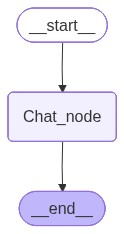

In [6]:
graph = StateGraph(ChatState)

## add nodes 
graph.add_node('Chat_node', Chat_node)

graph.add_edge(START, 'Chat_node')
graph.add_edge('Chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)
chatbot

In [7]:
thread_id = '1'
while True:

    user_message = input('Type here: ')
    print('User:', user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break 
    
    config = {'configurable':{'thread_id': thread_id}}
    response = chatbot.invoke({'message':[HumanMessage(content=user_message)]},config=config)

    print('AI:', response['message'][-1].content)

User: hi how are you 
AI: I'm doing great, thank you for asking! As an AI, I don't have feelings or personal experiences, but I'm fully operational and ready to help.

How are you today?
User: what are the top skills in 2026 to get job in AI engineer, ML engineer, data engineer 
AI: By 2026, the demand for AI, ML, and Data Engineers will continue to be incredibly strong, but the landscape will also have matured. Here's a breakdown of the top skills, emphasizing what will be critical in a few years:

## General Foundational Skills (for all three roles)

These are table stakes and will only become more important:

1.  **Programming Proficiency (Python):** Still the dominant language. Expertise in libraries like Pandas, NumPy, SciPy, Scikit-learn, and the ability to write clean, efficient, and testable code.
2.  **Cloud Platforms (AWS, Azure, GCP):** Deep understanding of at least one major cloud provider's AI/ML/Data services (e.g., S3, EC2, Lambda, Sagemaker, Redshift, BigQuery, Data Fa